<a href="https://colab.research.google.com/github/ccalvocm/24bp273032/blob/main/Gamma_Earth_S2DR3_Sentinel_2_Deep_Resolution_3_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Gamma Earth S2DR3 - Sentinel-2 Deep Resolution 3.0 (versión en español)
### Superresolución efectiva 10 bandas a 1 m de resolución espacial

---

> **Créditos y derechos de autor:**  
> Este cuaderno está basado en el módulo original **S2DR3 (Sentinel-2 Deep Resolution 3.0)** desarrollado por **Gamma.Earth**.  
> Para más información técnica, referencias o licencias comerciales, consulte:  
> 📄 [White Paper oficial](https://medium.com/@ya_71389/c71a601a2253)  
> 📩 Contacto: info@gamma.earth  
>  
> Adaptación al español realizada con fines educativos y demostrativos.

---

## 📘 Descripción

El módulo **S2DR3** permite obtener imágenes **Sentinel-2** de alta resolución (hasta **1 m/píxel**) aplicando técnicas avanzadas de **superresolución profunda (Deep Super-Resolution)** sobre las 10 bandas multiespectrales originales de 10 m y 20 m.

El resultado incluye 4 productos georreferenciados (archivos `.tif`) generados automáticamente en la carpeta `/content/output`:

| Producto | Descripción |
|-----------|--------------|
| `S2L2Ax10_T[MGRS]-[DATE]-[UID]_MS.tif` | Imagen multiespectral (10 bandas) |
| `S2L2Ax10_T[MGRS]-[DATE]-[UID]_TCI.tif` | Imagen RGB color verdadero |
| `S2L2Ax10_T[MGRS]-[DATE]-[UID]_NDVI.tif` | Imagen NDVI (color falso) |
| `S2L2Ax10_T[MGRS]-[DATE]-[UID]_IRP.tif` | Imagen infrarroja (color falso) |

**Orden de bandas:**  
`B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12`

---

## ⚙️ Instrucciones de uso (un clic)

1. Abrir este notebook en **Google Colab**  
2. En el menú superior, ir a: `Entorno de ejecución` → `Cambiar tipo de entorno de ejecución` → seleccionar **GPU T4**  
3. Ejecutar todas las celdas (`Ctrl+F9` o “Ejecutar todo”)  


In [1]:
# =============================================================
# 🛰️ INSTALACIÓN LIBRERÍAS Y COMPLEMENTOS
# =============================================================

# 1) Instalar s2dr3
!pip -q install https://storage.googleapis.com/0x7ff601307fa5/s2dr3-20250905.1-cp312-cp312-linux_x86_64.whl

# 2) Instalar numpy y scipy PRIMERO, por separado
!pip install -q --force-reinstall --no-deps numpy==1.26.4 scipy==1.13.0

# 3) Asegurarnos de tener Cython para compilar si hace falta
!pip install -q cython

# 4) Instalar scikit-image SIN build isolation, para que use el numpy 1.26.4 ya instalado
!pip install -q --force-reinstall --no-deps --no-cache-dir --no-build-isolation scikit-image==0.22.0


# 3) Reiniciar el kernel UNA sola vez
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.13.0 requires numpy<2.3,>=1.22.4, but you have numpy 2.5.0 which is incompatible.
tsfresh 0.21.2 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.
access 1.1.10.post3 requires scipy>=1.14.1, but you have scipy 1.13.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 333.2 MB/s eta 0:00:00


{'status': 'ok', 'restart': True}

In [ ]:
!ls -la /var/local/S2DR3/
!df -h /var/local /content
import os
os.remove("/var/local/S2DR3/S2DR3-GL-20240423.1")
!ls -la /var/local/S2DR3/   # should now be empty or missing that file

Fetching data for T19HCD-1cf2ceef1-20240825 .......... done. 
Processing S2L2A_T19HCD-1cf2ceef1-20240825_MS . done 
Postprocessing S2L2A_T19HCD-1cf2ceef1-20240825_MS ......... done

Find results at the following path: /content/output
Click the link below for preview:

https://gamayos.github.io/gamma-earth-api/s2dr3-demo-20250305.html?ds=CL-T19HCD-1cf2ceef1-20240825#15/-33.4386/-70.6161



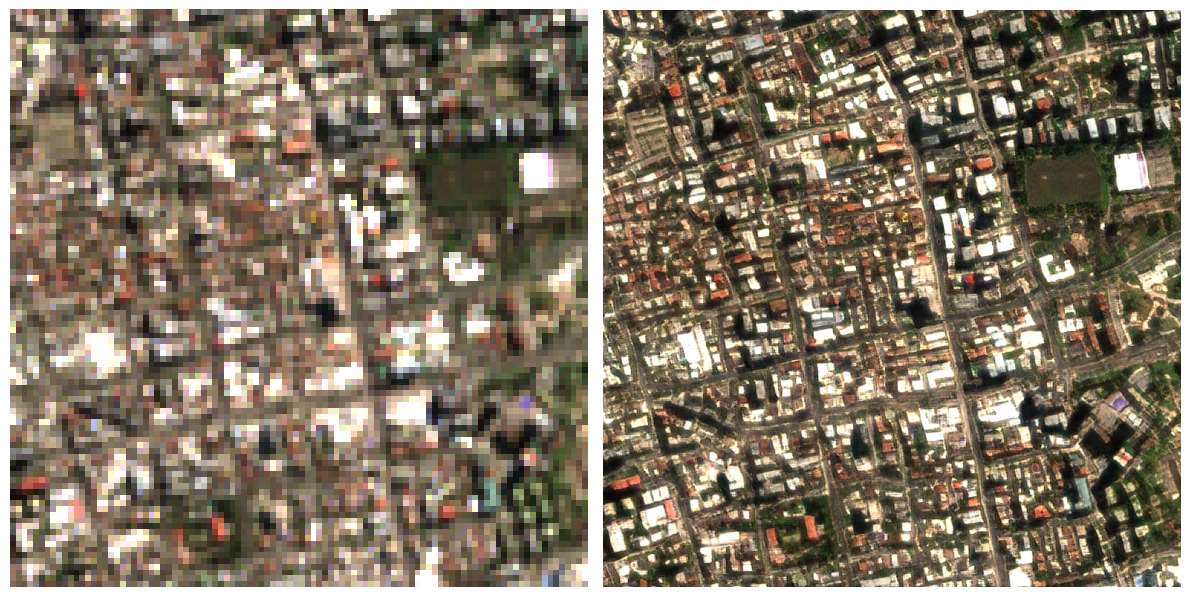

In [6]:
# =============================================================
# 🛰️ PROCESAMIENTO
# =============================================================

import s2dr3.inferutils

# =============================================================
# 🌎 Parámetros de entrada
# =============================================================

# Coordenadas del punto central (longitud, latitud)
# ⚠️ IMPORTANTE: el formato es (X, Y)

lonlat = (-70.616097,-33.4386186)  # Ejemplo: CIREN
# lonlat = (-79.203, -4.008)

# Fecha objetivo (AAAA-MM-DD)
# El modelo descargará la escena Sentinel-2 más cercana a esta fecha
# Nota: pueden existir nubes, se recomienda verificar en:
# https://browser.dataspace.copernicus.eu

# date = '2022-06-20'
date = '2024-08-23'

# =============================================================
# 🚀 Ejecución del modelo
# =============================================================

# Genera los productos en alta resolución (1 m/píxel)
# Los resultados se guardarán en /content/output
s2dr3.inferutils.test(lonlat, date)

Licencia
Copyright (c) Gamma Earth Sarl

El software se proporciona para pruebas, evaluación de rendimiento y validación. Todos los derechos reservados por el titular de los derechos de autor. Para ampliar su funcionalidad y uso comercial, contacte con info@gamma.earth.

Para publicaciones académicas relacionadas con S2DR3, utilice la siguiente referencia:

Yosef Akhtman, S2DR3: Superresolución efectiva de imagen única de 10 bandas y 10x para Sentinel-2. Medium: https://medium.com/@ya_71389/c71a601a2253